In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

In [2]:
# load
X =np.load('data/f3/updated_inputs.npy') #seems already normalized
y=np.load('data/f3/updated_outputs.npy') #negative values to maximize 

In [3]:
# The best
best_f = np.max(y)
best_idx = np.argmax(y)
print(f"Best current value: X = {X[best_idx]}, y = {best_f:.4f}")

Best current value: X = [0.49258141 0.61159319 0.34017639], y = -0.0348


In [4]:
# Compute distance for RBF lengthscale
distances = pdist(X, metric='euclidean') # compute mean distance between data

In [5]:
# GP model
noise_assumption = 1e-4
alpha = 1.5
rbf_lengthscale  = alpha*distances.mean()# 1.5 times mean distance
print('rbf_lengthscale=',rbf_lengthscale)
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
model.fit(X, y)

rbf_lengthscale= 0.9376411494494342


,kernel,RBF(length_scale=0.938)
,alpha,0.0001
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,np.float64(0.9376411494494342)
,kernel__length_scale_bounds,'fixed'


In [6]:
# Grid 3D for prediction
from scipy.stats import qmc

dim=3
n_grid = 5000 
sampler = qmc.LatinHypercube(d=dim, seed=42)
sample = sampler.random(n=n_grid)

# Compute boundaries
l_bounds = X.min(axis=0)  
u_bounds = X.max(axis=0)  
x_grid_d = qmc.scale(sample, l_bounds, u_bounds)

In [7]:
#GP prediction
post_mean, post_std = model.predict(x_grid_d, return_std=True)

In [8]:
###  New adquisition Function EI (same GP)

In [9]:
def expected_improvement(mean, std, best_f, xi=0.01):
    Z  = (mean - best_f - xi) / (std + 1e-9)
    ei = (mean - best_f - xi) * norm.cdf(Z) + std * norm.pdf(Z)
    ei[std <= 0.0] = 0.0
    return ei

ei_values = expected_improvement(post_mean, post_std, best_f, xi=0.01)

In [10]:
# Calculate the maximum value
idx_next  = np.argmax(ei_values)# simple grid
x_next    = x_grid_d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]
print(f"Suggested query (EI): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}, x3={x_next[2]:.8f}")
print('mean next=',post_mean[idx_next])
print('std next=',post_std[idx_next])

#best from EI
x_next_ei = x_next
y_next_ei = y_next

Suggested query (EI): x1=0.96339808, x2=0.92052285, x3=0.95040336
mean next= 0.01878003711809839
std next= 0.14446550477069428


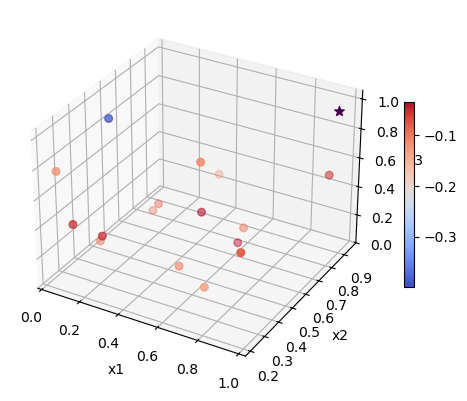

In [11]:
# graph
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
p3d = ax.scatter(X[:,0], X[:,1], X[:,2], s=30, c=y, cmap = cm.coolwarm)
# Added: Create colorbar to show the scale of y values
ax.scatter(x_grid_d[idx_next,0], x_grid_d[idx_next,1], x_grid_d[idx_next,2], c=post_mean[idx_next], marker='*', s=50)
plt.colorbar(p3d, ax=ax, shrink=0.5, aspect=20)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
plt.show()

In [12]:
    ## New adquisition Function UCB (same GP)

In [13]:
#UCB (maximize)
k = 1. #Initial exploration
acquisition = post_mean + k * post_std
idx_next = np.argmax(acquisition)
x_next = x_grid_d[idx_next]
y_next = post_mean[idx_next]
print(f"Proposed query (UCB): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}, x3={x_next[2]:.8f}")
print('mean next=',post_mean[idx_next])
print('std next=',post_std[idx_next])

#best from UCB
x_next_ucb = x_next
y_next_ucb = y_next

Proposed query (UCB): x1=0.96339808, x2=0.92052285, x3=0.95040336
mean next= 0.01878003711809839
std next= 0.14446550477069428


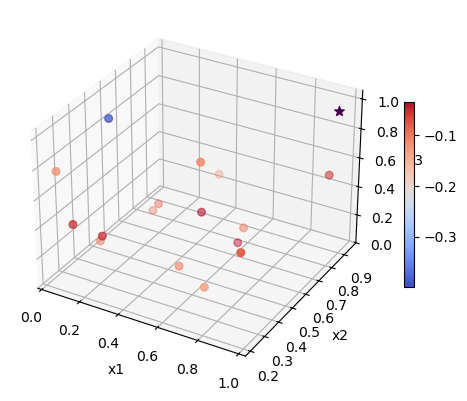

In [14]:
# Graph
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
p3d = ax.scatter(X[:,0], X[:,1], X[:,2], s=30, c=y, cmap = cm.coolwarm)
# Added: Create colorbar to show the scale of y values
ax.scatter(x_grid_d[idx_next,0], x_grid_d[idx_next,1], x_grid_d[idx_next,2], c=post_mean[idx_next], marker='*', s=50)
plt.colorbar(p3d, ax=ax, shrink=0.5, aspect=20)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
plt.show()

In [15]:
# Choose the best option between EI and UCB
if y_next_ei > y_next_ucb:
    x_next_out = x_next_ei
else:
    x_next_out = x_next_ucb

# Write output file
import os
folder = 'results'
filename = 'output_F3.txt'
file_path = os.path.join(folder, filename)
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(f"{x_next_out[0]:.6f} {x_next_out[1]:.6f} {x_next_out[2]:.6f}\n")